# Market Data Ingestion
Downloads 5 years of daily OHLCV data for AAPL, MSFT, NVDA, GOOGL, AMZN and the ^VIX index via yfinance.
All series are aligned on a common date index; gaps from market holidays are forward-filled.

In [15]:
import yfinance as yf
import pandas as pd
from pathlib import Path
from datetime import date, timedelta

# Configuration
TICKERS        = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "^VIX"]
EQUITY_TICKERS = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN"]
END_DATE       = date.today()
START_DATE     = END_DATE - timedelta(days=5 * 365)

DATA_DIR     = Path("data")
PRICES_PATH  = DATA_DIR / "prices.csv"
VOLUME_PATH  = DATA_DIR / "volume.csv"

# Load from CSV if available, otherwise download and save
if PRICES_PATH.exists() and VOLUME_PATH.exists():
    print("Loading pre-downloaded mega-cap data from CSV...")
    prices = pd.read_csv(PRICES_PATH, index_col="Date", parse_dates=True)
    volume = pd.read_csv(VOLUME_PATH, index_col="Date", parse_dates=True)
else:
    print(f"Fetching data from {START_DATE} to {END_DATE} for: {TICKERS}")
    raw = yf.download(
        tickers=TICKERS,
        start=START_DATE,
        end=END_DATE,
        interval="1d",
        group_by="ticker",
        auto_adjust=True,
        progress=True,
    )

    close_frames = {}
    for ticker in TICKERS:
        try:
            col_name = ticker.lstrip("^")
            close_frames[col_name] = raw[ticker]["Close"]
        except KeyError:
            print(f"  WARNING: 'Close' not found for {ticker} — skipping.")

    prices = pd.DataFrame(close_frames)
    prices.index = pd.to_datetime(prices.index)
    prices.index.name = "Date"
    prices.sort_index(inplace=True)
    prices.ffill(inplace=True)

    volume_frames = {}
    for ticker in EQUITY_TICKERS:
        try:
            volume_frames[ticker] = raw[ticker]["Volume"]
        except KeyError:
            print(f"  WARNING: 'Volume' not found for {ticker} — skipping.")

    volume = pd.DataFrame(volume_frames)
    volume.index = pd.to_datetime(volume.index)
    volume.index.name = "Date"
    volume.sort_index(inplace=True)
    volume.ffill(inplace=True)

    DATA_DIR.mkdir(exist_ok=True)
    prices.to_csv(PRICES_PATH)
    volume.to_csv(VOLUME_PATH)
    print(f"Saved to {PRICES_PATH} and {VOLUME_PATH}")

# Diagnostics
remaining_nulls = prices.isnull().sum()
print(f"\nShape: {prices.shape}  (rows x tickers)")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"\nResidual NaNs:\n{remaining_nulls}")

print("\nFirst five rows:")
prices.head()

Loading pre-downloaded mega-cap data from CSV...

Shape: (1254, 6)  (rows x tickers)
Date range: 2021-04-22 to 2026-04-20

Residual NaNs:
AAPL     0
MSFT     0
NVDA     0
GOOGL    0
AMZN     0
VIX      0
dtype: int64

First five rows:


,AAPL,MSFT,NVDA,GOOGL,AMZN,VIX
Date,,,,,,
2021-04-22,128.509003,246.769943,14.812916,111.702766,165.451996,18.709999
2021-04-23,130.827087,250.589020,15.226872,114.053841,167.044006,17.330000
2021-04-26,131.216690,250.972839,15.439086,114.549744,170.449997,17.639999
2021-04-27,130.895309,251.375839,15.343078,113.610008,170.871506,17.559999
2021-04-28,130.106308,244.265488,15.238344,116.985115,172.925003,17.280001


## Amihud Illiquidity Metric

Calculates the Amihud (2002) illiquidity ratio for each equity:

$$\text{ILLIQ}_t = \frac{|R_t|}{P_t \times V_t}$$

where $R_t$ is the log return, $P_t$ is the adjusted closing price, and $V_t$ is share volume.
A natural-log transformation (`log1p`) is then applied to compress the heavy right tail
and stabilise variance for time-series modelling.  
^VIX is excluded — it is a volatility index with no tradeable share volume.

In [16]:
import numpy as np

# prices and volume are already loaded in the cell above
equity_prices = prices[EQUITY_TICKERS].copy()

EPS = 1e-25


def amihud_illiquidity(
    close: pd.Series,
    vol: pd.Series,
    log_transform: bool = True,
) -> pd.Series:
    log_ret    = np.log(close / close.shift(1))
    abs_ret    = log_ret.abs()
    dollar_vol = close * vol

    raw_illiq = abs_ret / dollar_vol
    raw_illiq[dollar_vol <= 0] = np.nan
    raw_illiq.ffill(inplace=True)

    if log_transform:
        return np.log(raw_illiq + EPS)
    return raw_illiq


# Apply to all equity tickers
illiq_scores = pd.DataFrame(
    {
        ticker: amihud_illiquidity(
            close=equity_prices[ticker],
            vol=volume[ticker],
            log_transform=True,
        )
        for ticker in EQUITY_TICKERS
    }
)
illiq_scores.index.name = "Date"

# Diagnostics
print("Amihud Log-Illiquidity Scores — descriptive statistics:")
print(illiq_scores.describe().round(4))
print(f"\nResidual NaNs:\n{illiq_scores.isnull().sum()}")

print("\nFirst five rows:")
illiq_scores.head()

Amihud Log-Illiquidity Scores — descriptive statistics:
            AAPL       MSFT       NVDA      GOOGL       AMZN
count  1253.0000  1253.0000  1253.0000  1253.0000  1253.0000
mean    -28.1173   -27.8130   -27.8513   -26.9835   -27.5551
std       1.7986     1.4160     1.7514     1.6249     1.8498
min     -57.5646   -57.5646   -57.5646   -57.5646   -57.5646
25%     -28.6140   -28.3827   -28.5018   -27.5114   -28.0519
50%     -27.8343   -27.5788   -27.6943   -26.7399   -27.2277
75%     -27.2879   -26.9855   -26.9247   -26.1891   -26.7154
max     -26.0294   -25.6518   -25.1339   -24.8970   -25.4627

Residual NaNs:
AAPL     1
MSFT     1
NVDA     1
GOOGL    1
AMZN     1
dtype: int64

First five rows:


,AAPL,MSFT,NVDA,GOOGL,AMZN
Date,,,,,
2021-04-22,NaN,NaN,NaN,NaN,NaN
2021-04-23,-27.078700,-26.581773,-25.557029,-25.793152,-27.738874
2021-04-26,-28.713627,-28.806844,-26.119802,-27.463658,-27.437804
2021-04-27,-28.890556,-29.211871,-26.726629,-27.140256,-29.297854
2021-04-28,-28.472133,-26.712935,-26.867226,-26.504332,-27.924414


## Small/Mid-Cap Universe — Amihud Illiquidity Pipeline

A second universe of five high-volatility, lower-liquidity names is run through the identical Amihud pipeline:

| Ticker | Name | Sector note |
|--------|------|-------------|
| MARA | Marathon Digital | Bitcoin miner — volume driven by crypto sentiment |
| RIOT | Riot Platforms | Bitcoin miner — near-identical driver to MARA |
| SMCI | Super Micro Computer | Server hardware — high beta to AI capex cycle |
| SOFI | SoFi Technologies | Fintech neobank — rate-sensitive, retail-heavy float |
| RIVN | Rivian Automotive | EV OEM — IPO'd Nov 2021, so ~3.5 years of history |

Because RIVN listed mid-window, its pre-IPO rows are NaN and are left as-is (no back-fill). The comparison chart aligns all series on the intersection of available dates.

In [17]:
SC_TICKERS = ["MARA", "RIOT", "SMCI", "SOFI", "RIVN"]

SC_PRICES_PATH = DATA_DIR / "sc_prices.csv"
SC_VOLUME_PATH = DATA_DIR / "sc_volume.csv"

# Load from CSV if available, otherwise download and save
if SC_PRICES_PATH.exists() and SC_VOLUME_PATH.exists():
    print("Loading pre-downloaded small-cap data from CSV...")
    sc_prices = pd.read_csv(SC_PRICES_PATH, index_col="Date", parse_dates=True)
    sc_volume = pd.read_csv(SC_VOLUME_PATH, index_col="Date", parse_dates=True)
else:
    print(f"Fetching small-cap data from {START_DATE} to {END_DATE} for: {SC_TICKERS}")
    raw_sc = yf.download(
        tickers=SC_TICKERS,
        start=START_DATE,
        end=END_DATE,
        interval="1d",
        group_by="ticker",
        auto_adjust=True,
        progress=True,
    )

    sc_close_frames  = {}
    sc_volume_frames = {}

    for ticker in SC_TICKERS:
        try:
            sc_close_frames[ticker]  = raw_sc[ticker]["Close"]
            sc_volume_frames[ticker] = raw_sc[ticker]["Volume"]
        except KeyError:
            print(f"  WARNING: data not found for {ticker} — skipping.")

    sc_prices = pd.DataFrame(sc_close_frames)
    sc_volume = pd.DataFrame(sc_volume_frames)

    for df in (sc_prices, sc_volume):
        df.index = pd.to_datetime(df.index)
        df.index.name = "Date"
        df.sort_index(inplace=True)
        df.ffill(inplace=True)

    sc_prices.to_csv(SC_PRICES_PATH)
    sc_volume.to_csv(SC_VOLUME_PATH)
    print(f"Saved to {SC_PRICES_PATH} and {SC_VOLUME_PATH}")

# Run Amihud pipeline on small-caps
illiq_scores_sc = pd.DataFrame(
    {
        ticker: amihud_illiquidity(
            close=sc_prices[ticker],
            vol=sc_volume[ticker],
            log_transform=True,
        )
        for ticker in SC_TICKERS
    }
)
illiq_scores_sc.index.name = "Date"

# Diagnostics
print("\nSmall-Cap Amihud Log-Illiquidity — descriptive statistics:")
print(illiq_scores_sc.describe().round(4))
print(f"\nResidual NaNs (RIVN pre-IPO gap expected):\n{illiq_scores_sc.isnull().sum()}")

compare_stats = pd.DataFrame({
    "Mega mean" : illiq_scores.mean(),
    "Mega std"  : illiq_scores.std(),
    "SC mean"   : illiq_scores_sc.mean(),
    "SC std"    : illiq_scores_sc.std(),
}).round(4)

print("\nMega-cap vs Small-cap — mean and std of log-illiquidity:")
print(compare_stats)

Loading pre-downloaded small-cap data from CSV...

Small-Cap Amihud Log-Illiquidity — descriptive statistics:
            MARA       RIOT       SMCI       SOFI       RIVN
count  1253.0000  1253.0000  1253.0000  1253.0000  1112.0000
mean    -23.6206   -22.9224   -23.4151   -23.9699   -24.0643
std       3.0447     2.8867     2.5249     3.2377     2.4837
min     -57.5646   -57.5646   -57.5646   -57.5646   -57.5646
25%     -24.1616   -23.4040   -25.0417   -24.5057   -24.4488
50%     -23.3085   -22.6097   -23.8601   -23.5577   -23.6987
75%     -22.4819   -21.9248   -21.2961   -22.8960   -23.1378
max     -19.6834   -19.5081   -18.6011   -18.5471   -22.0351

Residual NaNs (RIVN pre-IPO gap expected):
MARA      1
RIOT      1
SMCI      1
SOFI      1
RIVN    142
dtype: int64

Mega-cap vs Small-cap — mean and std of log-illiquidity:
       Mega mean  Mega std  SC mean  SC std
AAPL    -28.1173    1.7986      NaN     NaN
AMZN    -27.5551    1.8498      NaN     NaN
GOOGL   -26.9835    1.6249      Na

## Exploratory Data Analysis

### Visualisation 1 — Correlation Heatmap of Log-Illiquidity Scores
Pearson correlations across the five equities reveal whether illiquidity shocks are idiosyncratic or sector-wide.  
High off-diagonal values suggest common liquidity drivers (e.g. macro stress, index rebalancing).

### Visualisation 2 — Average Tech Illiquidity vs. VIX (Dual-Axis)
Overlays the equal-weighted mean log-illiquidity of the five stocks against the VIX closing level.  
A strong co-movement would support using VIX as a leading liquidity-stress indicator in the model.

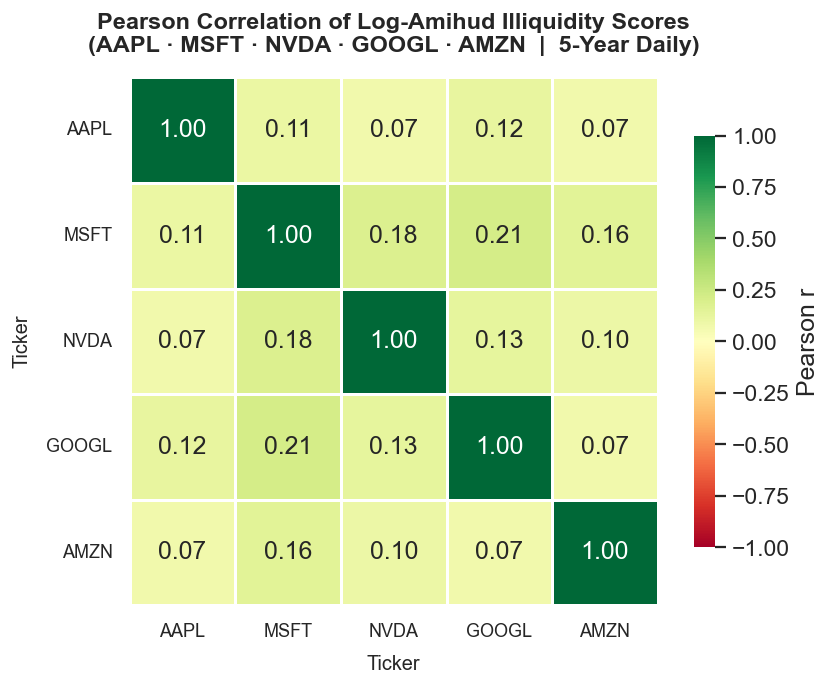

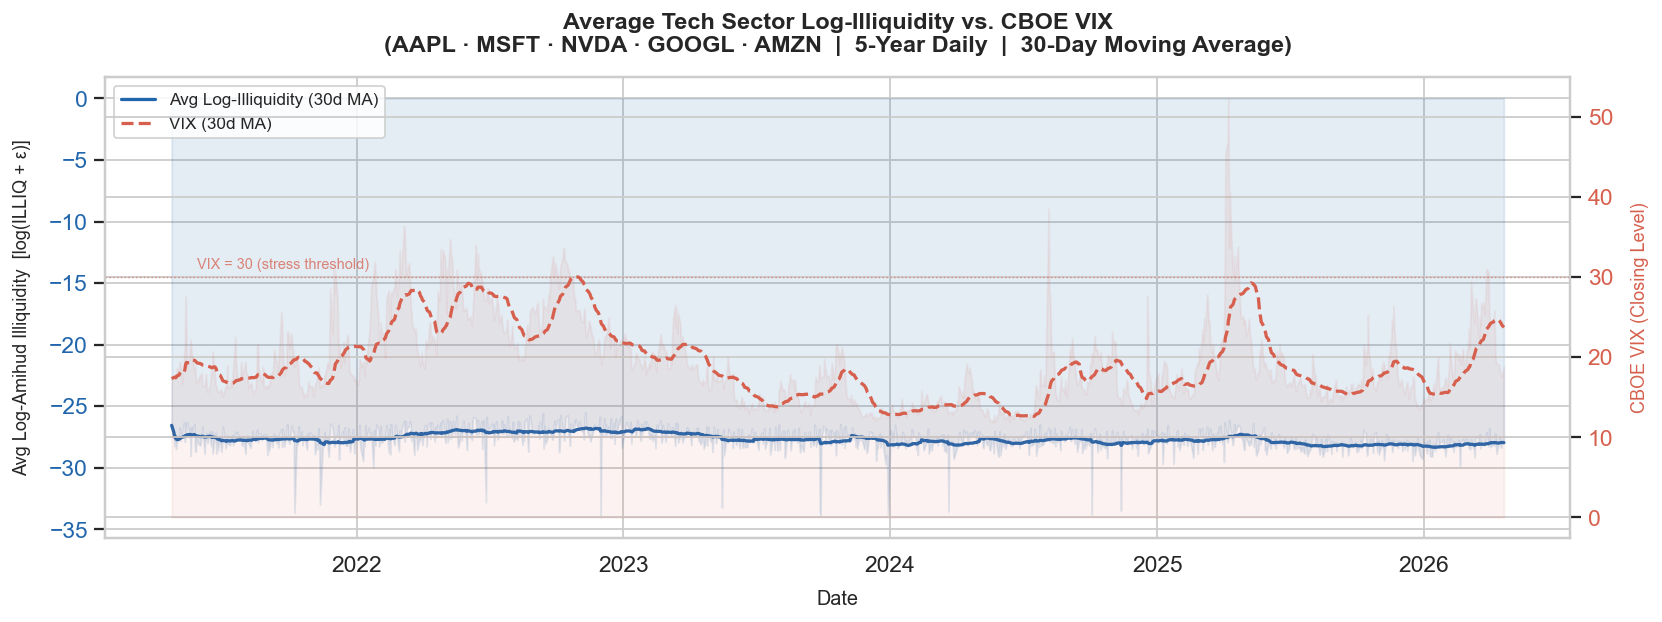

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams["figure.dpi"] = 130

# Correlation heatmap
corr_matrix = illiq_scores.corr(method="pearson")

fig1, ax1 = plt.subplots(figsize=(7, 5.5))

sns.heatmap(
    corr_matrix,
    ax=ax1,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.78, "label": "Pearson r"},
)

ax1.set_title(
    "Pearson Correlation of Log-Amihud Illiquidity Scores\n"
    "(AAPL · MSFT · NVDA · GOOGL · AMZN  |  5-Year Daily)",
    fontsize=13, fontweight="bold", pad=14,
)
ax1.set_xlabel("Ticker", fontsize=11, labelpad=8)
ax1.set_ylabel("Ticker", fontsize=11, labelpad=8)
ax1.tick_params(axis="both", labelsize=10, rotation=0)

fig1.tight_layout()
plt.show()

# Dual-axis: average tech illiquidity vs VIX
avg_illiq  = illiq_scores.mean(axis=1).rename("Avg Log-Illiquidity")
vix_series = prices["VIX"].copy()

combined = pd.concat([avg_illiq, vix_series], axis=1, join="inner")
combined.columns = ["Avg Log-Illiquidity", "VIX"]
combined.dropna(inplace=True)

WINDOW = 30
illiq_smooth = combined["Avg Log-Illiquidity"].rolling(WINDOW, min_periods=1).mean()
vix_smooth   = combined["VIX"].rolling(WINDOW, min_periods=1).mean()

fig2, ax_left = plt.subplots(figsize=(13, 5))
ax_right = ax_left.twinx()

ILLIQ_COLOR = "#2166AC"
VIX_COLOR   = "#D6604D"

ax_left.fill_between(combined.index, combined["Avg Log-Illiquidity"],
                     alpha=0.12, color=ILLIQ_COLOR, label="_nolegend_")
ax_left.plot(illiq_smooth.index, illiq_smooth,
             color=ILLIQ_COLOR, linewidth=1.8,
             label=f"Avg Log-Illiquidity ({WINDOW}d MA)")

ax_right.fill_between(combined.index, combined["VIX"],
                      alpha=0.08, color=VIX_COLOR, label="_nolegend_")
ax_right.plot(vix_smooth.index, vix_smooth,
              color=VIX_COLOR, linewidth=1.8, linestyle="--",
              label=f"VIX ({WINDOW}d MA)")

ax_left.set_title(
    "Average Tech Sector Log-Illiquidity vs. CBOE VIX\n"
    "(AAPL · MSFT · NVDA · GOOGL · AMZN  |  5-Year Daily  |  30-Day Moving Average)",
    fontsize=13, fontweight="bold", pad=14,
)
ax_left.set_xlabel("Date", fontsize=11, labelpad=8)
ax_left.set_ylabel("Avg Log-Amihud Illiquidity  [log(ILLIQ + ε)]", fontsize=10, labelpad=10)
ax_right.set_ylabel("CBOE VIX (Closing Level)", fontsize=10, labelpad=10, color=VIX_COLOR)

ax_left.tick_params(axis="y", labelcolor=ILLIQ_COLOR)
ax_right.tick_params(axis="y", labelcolor=VIX_COLOR)

ax_left.xaxis.set_major_locator(mdates.YearLocator())
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_left.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
plt.setp(ax_left.xaxis.get_majorticklabels(), rotation=0, ha="center")

lines_left,  labels_left  = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right,
               loc="upper left", fontsize=9.5, framealpha=0.85)

ax_right.axhline(30, color=VIX_COLOR, linewidth=0.8, linestyle=":", alpha=0.6)
ax_right.annotate(
    "VIX = 30 (stress threshold)",
    xy=(combined.index[int(len(combined) * 0.02)], 31),
    fontsize=8, color=VIX_COLOR, alpha=0.75,
)

fig2.tight_layout()
plt.show()

Average log-illiquidity levels by universe:
  Mega-cap  mean = -27.664  std = 0.917
  Small-cap mean = -23.562  std = 1.510

  Small-caps are ~4.10 log-units more illiquid on average.



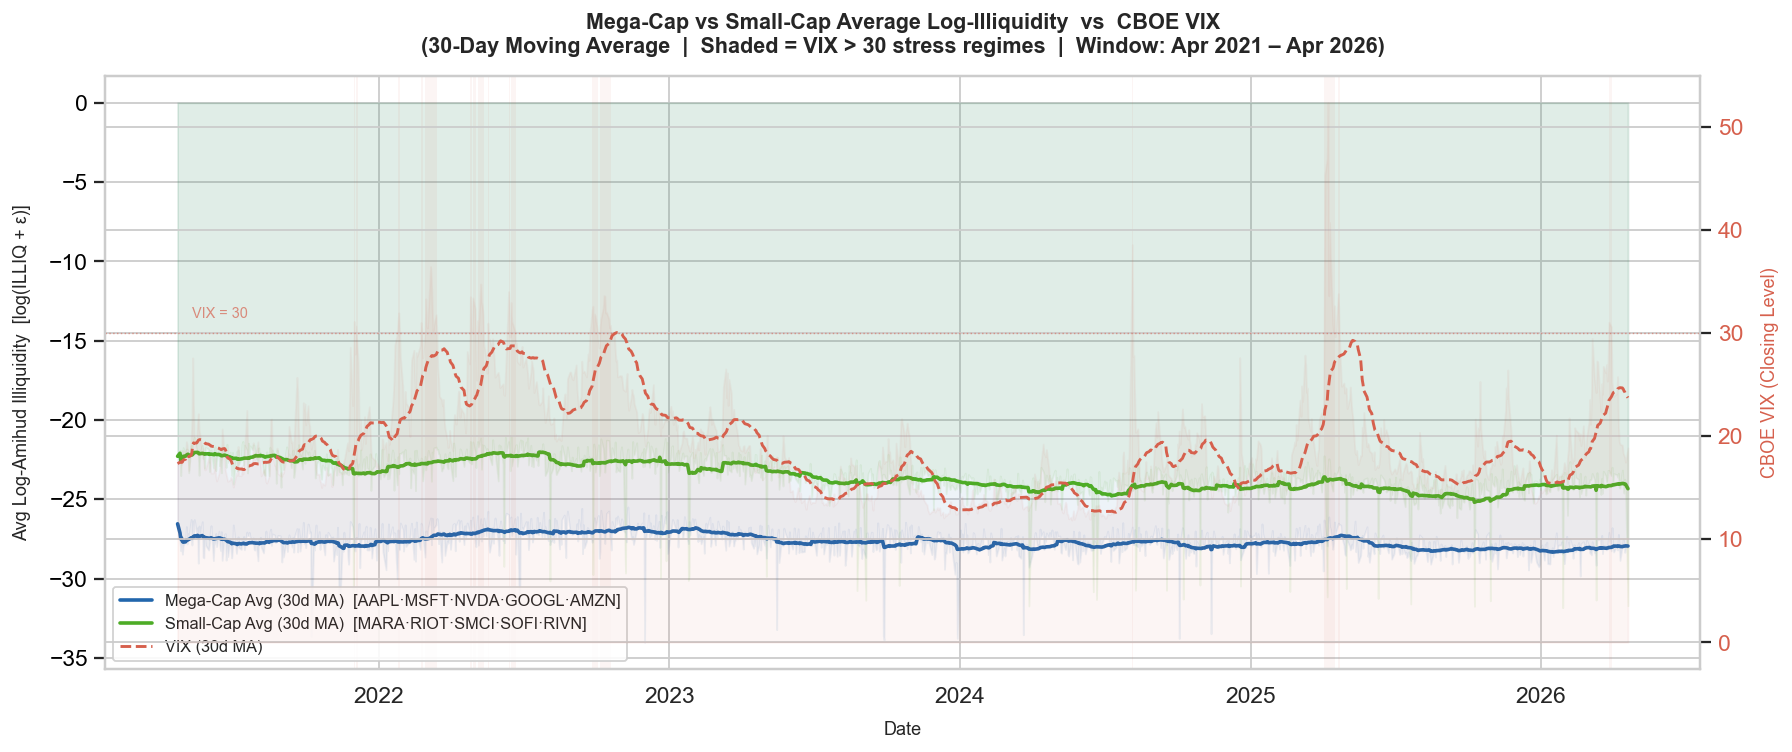

In [19]:
WINDOW = 30

avg_mega = illiq_scores.mean(axis=1).rename("Mega-Cap Avg")
avg_sc   = illiq_scores_sc.mean(axis=1).rename("Small-Cap Avg")

trio = pd.concat([avg_mega, avg_sc, prices["VIX"]], axis=1, join="inner").dropna()
trio.columns = ["Mega-Cap Avg", "Small-Cap Avg", "VIX"]

mega_smooth = trio["Mega-Cap Avg"].rolling(WINDOW, min_periods=1).mean()
sc_smooth   = trio["Small-Cap Avg"].rolling(WINDOW, min_periods=1).mean()
vix_smooth  = trio["VIX"].rolling(WINDOW, min_periods=1).mean()

print("Average log-illiquidity levels by universe:")
print(f"  Mega-cap  mean = {trio['Mega-Cap Avg'].mean():.3f}  std = {trio['Mega-Cap Avg'].std():.3f}")
print(f"  Small-cap mean = {trio['Small-Cap Avg'].mean():.3f}  std = {trio['Small-Cap Avg'].std():.3f}")
print(f"\n  Small-caps are ~{trio['Small-Cap Avg'].mean() - trio['Mega-Cap Avg'].mean():.2f} log-units more illiquid on average.\n")

MEGA_COLOR = "#2166AC"
SC_COLOR   = "#4DAC26"
VIX_COLOR  = "#D6604D"

fig, ax_illiq = plt.subplots(figsize=(14, 6))
ax_vix = ax_illiq.twinx()

# Left axis: both illiquidity series
ax_illiq.fill_between(trio.index, trio["Mega-Cap Avg"], alpha=0.08, color=MEGA_COLOR)
ax_illiq.fill_between(trio.index, trio["Small-Cap Avg"], alpha=0.08, color=SC_COLOR)
ax_illiq.plot(mega_smooth.index, mega_smooth, color=MEGA_COLOR, linewidth=2.0,
              label=f"Mega-Cap Avg ({WINDOW}d MA)  [AAPL·MSFT·NVDA·GOOGL·AMZN]")
ax_illiq.plot(sc_smooth.index, sc_smooth, color=SC_COLOR, linewidth=2.0,
              label=f"Small-Cap Avg ({WINDOW}d MA)  [MARA·RIOT·SMCI·SOFI·RIVN]")

# Right axis: VIX
ax_vix.fill_between(trio.index, trio["VIX"], alpha=0.06, color=VIX_COLOR)
ax_vix.plot(vix_smooth.index, vix_smooth, color=VIX_COLOR, linewidth=1.6,
            linestyle="--", label=f"VIX ({WINDOW}d MA)")
ax_vix.axhline(30, color=VIX_COLOR, linewidth=0.8, linestyle=":", alpha=0.55)
ax_vix.annotate("VIX = 30", xy=(trio.index[int(len(trio) * 0.01)], 31.5),
                fontsize=8, color=VIX_COLOR, alpha=0.7)

# Shade VIX > 30 stress periods
stress = trio["VIX"] > 30
in_stress = False
stress_start = None
for date, flag in stress.items():
    if flag and not in_stress:
        stress_start = date
        in_stress = True
    elif not flag and in_stress:
        ax_illiq.axvspan(stress_start, date, color=VIX_COLOR, alpha=0.06, linewidth=0)
        in_stress = False
if in_stress:
    ax_illiq.axvspan(stress_start, trio.index[-1], color=VIX_COLOR, alpha=0.06, linewidth=0)

# Labels and formatting
ax_illiq.set_title(
    "Mega-Cap vs Small-Cap Average Log-Illiquidity  vs  CBOE VIX\n"
    f"(30-Day Moving Average  |  Shaded = VIX > 30 stress regimes  |  "
    f"Window: {trio.index[0].strftime('%b %Y')} – {trio.index[-1].strftime('%b %Y')})",
    fontsize=12, fontweight="bold", pad=13,
)
ax_illiq.set_xlabel("Date", fontsize=10, labelpad=8)
ax_illiq.set_ylabel("Avg Log-Amihud Illiquidity  [log(ILLIQ + ε)]", fontsize=10, labelpad=10)
ax_vix.set_ylabel("CBOE VIX (Closing Level)", fontsize=10, labelpad=10, color=VIX_COLOR)

ax_illiq.tick_params(axis="y", labelcolor="black")
ax_vix.tick_params(axis="y", labelcolor=VIX_COLOR)

ax_illiq.xaxis.set_major_locator(mdates.YearLocator())
ax_illiq.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_illiq.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
plt.setp(ax_illiq.xaxis.get_majorticklabels(), rotation=0, ha="center")

lines_l, labels_l = ax_illiq.get_legend_handles_labels()
lines_r, labels_r = ax_vix.get_legend_handles_labels()
ax_illiq.legend(lines_l + lines_r, labels_l + labels_r, loc="lower left", fontsize=9, framealpha=0.88)

fig.tight_layout()
plt.show()

## Time-Series Modelling — ARIMAX on the PC1 Liquidity Factor

**Pipeline:**
1. **PCA** — reduce the five log-illiquidity series to a single latent factor (PC1) that captures the dominant co-movement.
2. **ADF Test** — verify PC1 is stationary before fitting any ARIMA-family model; differencing order `d` is set accordingly.
3. **AIC Grid Search** — exhaustive search over `p ∈ [0,3]`, `d ∈ [0,1]`, `q ∈ [0,3]` to find the optimal ARIMAX order.
4. **ARIMAX Fit** — PC1 is the endogenous target; the daily VIX closing level is the exogenous regressor.
5. **Actual vs. Predicted Plot** — in-sample fit visualised over the most recent 60 trading days.

PCA Explained Variance
  PC1: 30.10%  <-- selected
  PC2: 18.98%  
  PC3: 18.45%  
  PC4: 17.27%  
  PC5: 15.21%  

  PC1 captures 30.10% of total log-illiquidity variance.

Augmented Dickey-Fuller Test on PC1
  Test Statistic : -3.5075
  p-value        : 0.0078
  Lags Used      : 19  |  Observations: 1233
  Critical Values:
    1%: -3.4357
    5%: -2.8639
    10%: -2.5680

  Result: Reject H0 — PC1 is stationary (d = 0 is valid).

Modelling window: 2021-04-23 to 2026-04-20  |  Observations: 1253

ARIMAX AIC Grid Search
  Search space: p in [0, 1, 2, 3], d in [0, 1], q in [0, 1, 2, 3]  |  Total candidates: 32

  Top 10 models by AIC:
 p  d  q         AIC
 0  1  1 3855.568469
 0  1  2 3856.416487
 1  1  1 3856.487207
 0  1  3 3857.200534
 2  1  1 3857.405027
 3  1  1 3857.780522
 1  0  1 3859.328840
 1  1  2 3859.560161
 1  0  2 3860.127272
 2  0  1 3860.202896

  Optimal order: ARIMAX(0, 1, 1)  (AIC = 3855.5685)

ARIMAX Model Results
  Model        : ARIMAX(0, 1, 1)
  Observations : 12

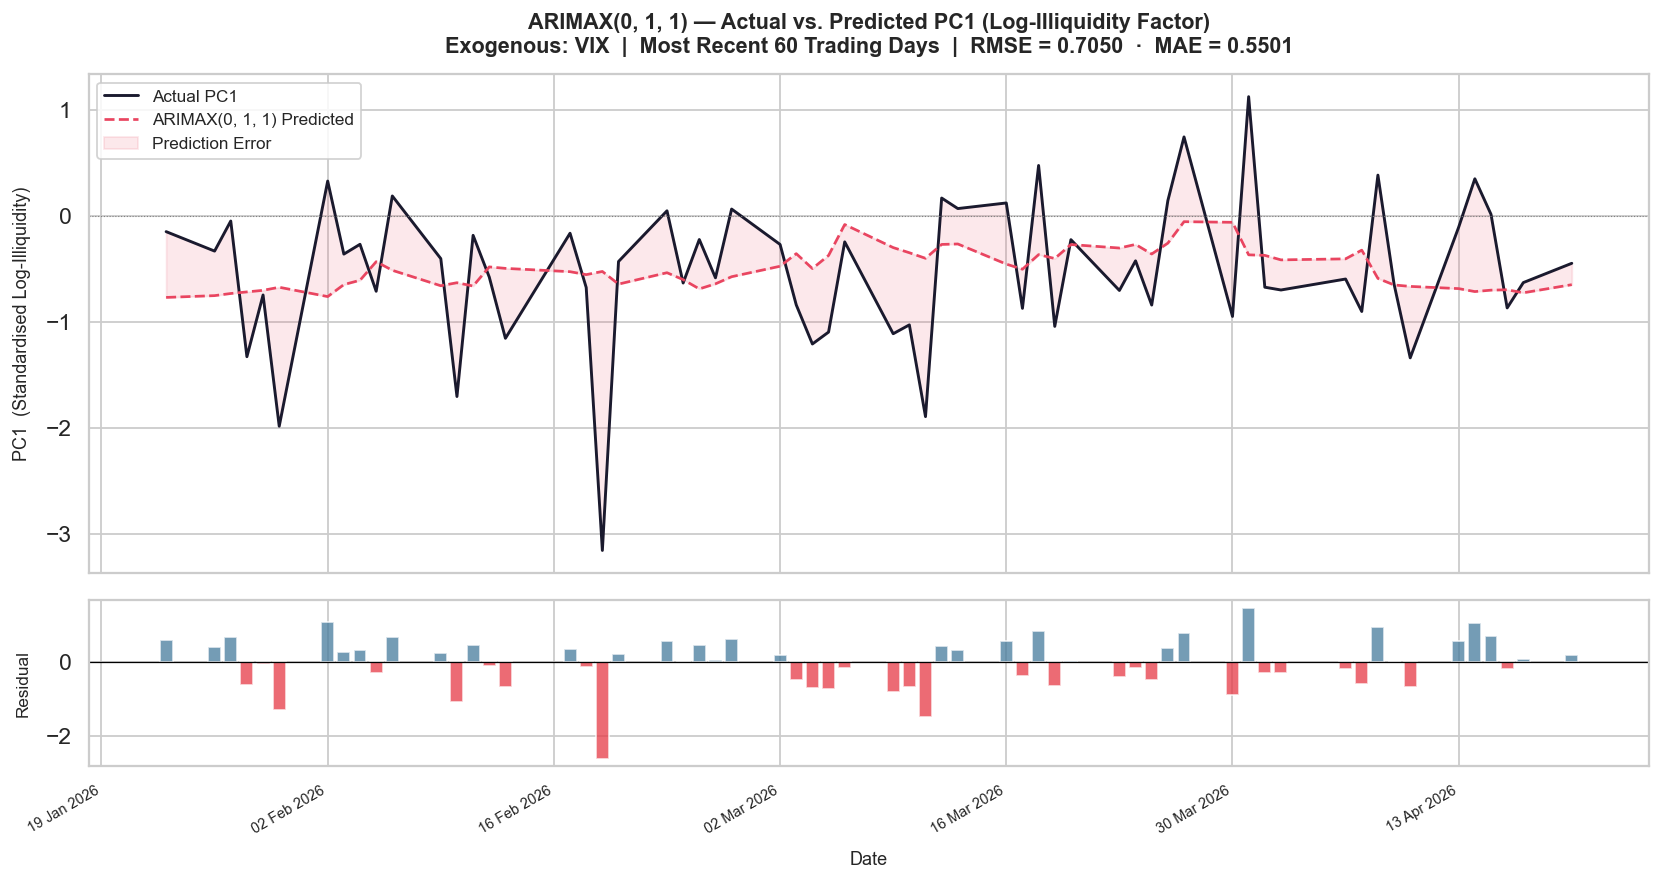

In [20]:
import itertools
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# Step 1: PCA — reduce five log-illiquidity series to PC1
illiq_clean = illiq_scores.dropna()
scaler      = StandardScaler()
X_scaled    = scaler.fit_transform(illiq_clean)

pca = PCA(n_components=len(EQUITY_TICKERS))
pca.fit(X_scaled)

pc1 = pd.Series(
    pca.transform(X_scaled)[:, 0],
    index=illiq_clean.index,
    name="PC1_LogIlliquidity",
)

explained = pca.explained_variance_ratio_
print("PCA Explained Variance")
for i, ev in enumerate(explained, 1):
    print(f"  PC{i}: {ev:.2%}  {'<-- selected' if i == 1 else ''}")
print(f"\n  PC1 captures {explained[0]:.2%} of total log-illiquidity variance.\n")

# Step 2: ADF stationarity test on PC1
adf_stat, adf_pval, adf_lags, adf_nobs, adf_crit, _ = adfuller(pc1, autolag="AIC")

print("Augmented Dickey-Fuller Test on PC1")
print(f"  Test Statistic : {adf_stat:.4f}")
print(f"  p-value        : {adf_pval:.4f}")
print(f"  Lags Used      : {adf_lags}  |  Observations: {adf_nobs}")
print("  Critical Values:")
for level, cv in adf_crit.items():
    print(f"    {level}: {cv:.4f}")

if adf_pval < 0.05:
    print("\n  Result: Reject H0 — PC1 is stationary (d = 0 is valid).")
    adf_d_max = 1
else:
    print("\n  Result: Fail to reject H0 — PC1 is non-stationary (d >= 1 required).")
    adf_d_max = 2

# Step 3: Align PC1 with VIX
vix_exog = prices["VIX"].reindex(pc1.index).ffill()
ts_df    = pd.concat([pc1, vix_exog], axis=1, join="inner").dropna()
ts_df.columns = ["PC1", "VIX"]

endog = ts_df["PC1"]
exog  = ts_df[["VIX"]]

print(f"\nModelling window: {ts_df.index[0].date()} to {ts_df.index[-1].date()}  |  Observations: {len(ts_df)}\n")

# Step 4: AIC grid search
p_vals = range(0, 4)
d_vals = range(0, adf_d_max + 1)
q_vals = range(0, 4)

aic_records = []
best_aic   = np.inf
best_order = (1, 0, 0)

print("ARIMAX AIC Grid Search")
print(f"  Search space: p in {list(p_vals)}, d in {list(d_vals)}, q in {list(q_vals)}  |  Total candidates: {len(p_vals) * len(d_vals) * len(q_vals)}\n")

for p, d, q in itertools.product(p_vals, d_vals, q_vals):
    try:
        fit = ARIMA(endog, exog=exog, order=(p, d, q)).fit(
            method_kwargs={"warn_convergence": False}
        )
        aic_records.append({"p": p, "d": d, "q": q, "AIC": fit.aic})
        if fit.aic < best_aic:
            best_aic   = fit.aic
            best_order = (p, d, q)
    except Exception:
        continue

aic_table = pd.DataFrame(aic_records).sort_values("AIC").reset_index(drop=True)
print("  Top 10 models by AIC:")
print(aic_table.head(10).to_string(index=False))
print(f"\n  Optimal order: ARIMAX{best_order}  (AIC = {best_aic:.4f})\n")

# Step 5: Fit optimal ARIMAX
best_model = ARIMA(endog, exog=exog, order=best_order).fit()

print("ARIMAX Model Results")
print(f"  Model        : ARIMAX{best_order}")
print(f"  Observations : {int(best_model.nobs)}  |  AIC: {best_model.aic:.2f}  |  BIC: {best_model.bic:.2f}")
print(f"  {'Coefficient':<12} {'Value':>10} {'Std Err':>10} {'p-value':>10}")
for name in best_model.params.index:
    print(f"  {name:<12} {best_model.params[name]:>10.4f} {best_model.bse[name]:>10.4f} {best_model.pvalues[name]:>10.4f}")

# Step 6: In-sample fit — last 60 trading days
LOOKBACK = 60

actual    = endog.iloc[-LOOKBACK:]
predicted = best_model.fittedvalues.iloc[-LOOKBACK:]
residuals = actual - predicted

rmse = np.sqrt((residuals ** 2).mean())
mae  = residuals.abs().mean()

print(f"\nIn-Sample Fit Metrics (last {LOOKBACK} days)")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")

# Plot
fig, (ax_main, ax_resid) = plt.subplots(
    2, 1, figsize=(13, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)

ax_main.plot(actual.index, actual.values, color="#1a1a2e", linewidth=1.6, label="Actual PC1")
ax_main.plot(predicted.index, predicted.values, color="#e94560", linewidth=1.5,
             linestyle="--", label=f"ARIMAX{best_order} Predicted")
ax_main.fill_between(actual.index, actual.values, predicted.values,
                     alpha=0.12, color="#e94560", label="Prediction Error")
ax_main.set_title(
    f"ARIMAX{best_order} — Actual vs. Predicted PC1 (Log-Illiquidity Factor)\n"
    f"Exogenous: VIX  |  Most Recent {LOOKBACK} Trading Days  |  "
    f"RMSE = {rmse:.4f}  ·  MAE = {mae:.4f}",
    fontsize=12, fontweight="bold", pad=12,
)
ax_main.set_ylabel("PC1  (Standardised Log-Illiquidity)", fontsize=10, labelpad=8)
ax_main.legend(loc="upper left", fontsize=9.5, framealpha=0.85)
ax_main.axhline(0, color="grey", linewidth=0.6, linestyle=":")

ax_resid.bar(residuals.index, residuals.values,
             color=np.where(residuals.values >= 0, "#457b9d", "#e63946"),
             width=0.8, alpha=0.75)
ax_resid.axhline(0, color="black", linewidth=0.7)
ax_resid.set_ylabel("Residual", fontsize=9.5, labelpad=8)
ax_resid.set_xlabel("Date", fontsize=10, labelpad=8)

ax_resid.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
ax_resid.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
plt.setp(ax_resid.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

fig.tight_layout()
plt.show()

## ARIMAX(0,1,1) — Small-Cap PC1 vs Mega-Cap Model Comparison

The identical `ARIMAX(0,1,1)` specification is fitted on the small-cap PC1 factor with VIX as the exogenous regressor.

**Hypothesis:** small-cap illiquidity co-moves more strongly with VIX (as shown in Visualisation 3), so VIX should explain a greater share of variance in the small-cap PC1, producing **lower RMSE and MAE** than the mega-cap fit.

Small-Cap PCA Explained Variance
  PC1: 28.38%  <-- selected
  PC2: 20.01%  
  PC3: 19.24%  
  PC4: 16.94%  
  PC5: 15.43%  

  SC_PC1 captures 28.38% of small-cap variance (vs 30.10% for mega-caps).

ADF Test on SC_PC1
  Test Statistic : -2.3976
  p-value        : 0.1424  |  Lags: 14
  Critical Value (1%): -3.4363
  Critical Value (5%): -2.8642
  Critical Value (10%): -2.5682

  Result: Fail to reject H0 — SC_PC1 is non-stationary.

Small-Cap ARIMAX(0, 1, 1)
  Modelling window: 2021-11-11 to 2026-04-20  |  Observations: 1112

ARIMAX Model Results
  Model        : ARIMAX(0, 1, 1)
  Observations : 1112  |  AIC: 3073.42  |  BIC: 3088.46
  Coefficient       Value    Std Err    p-value
  VIX              0.0317     0.0062     0.0000
  ma.L1           -0.9683     0.0087     0.0000
  sigma2           0.9236     0.0108     0.0000


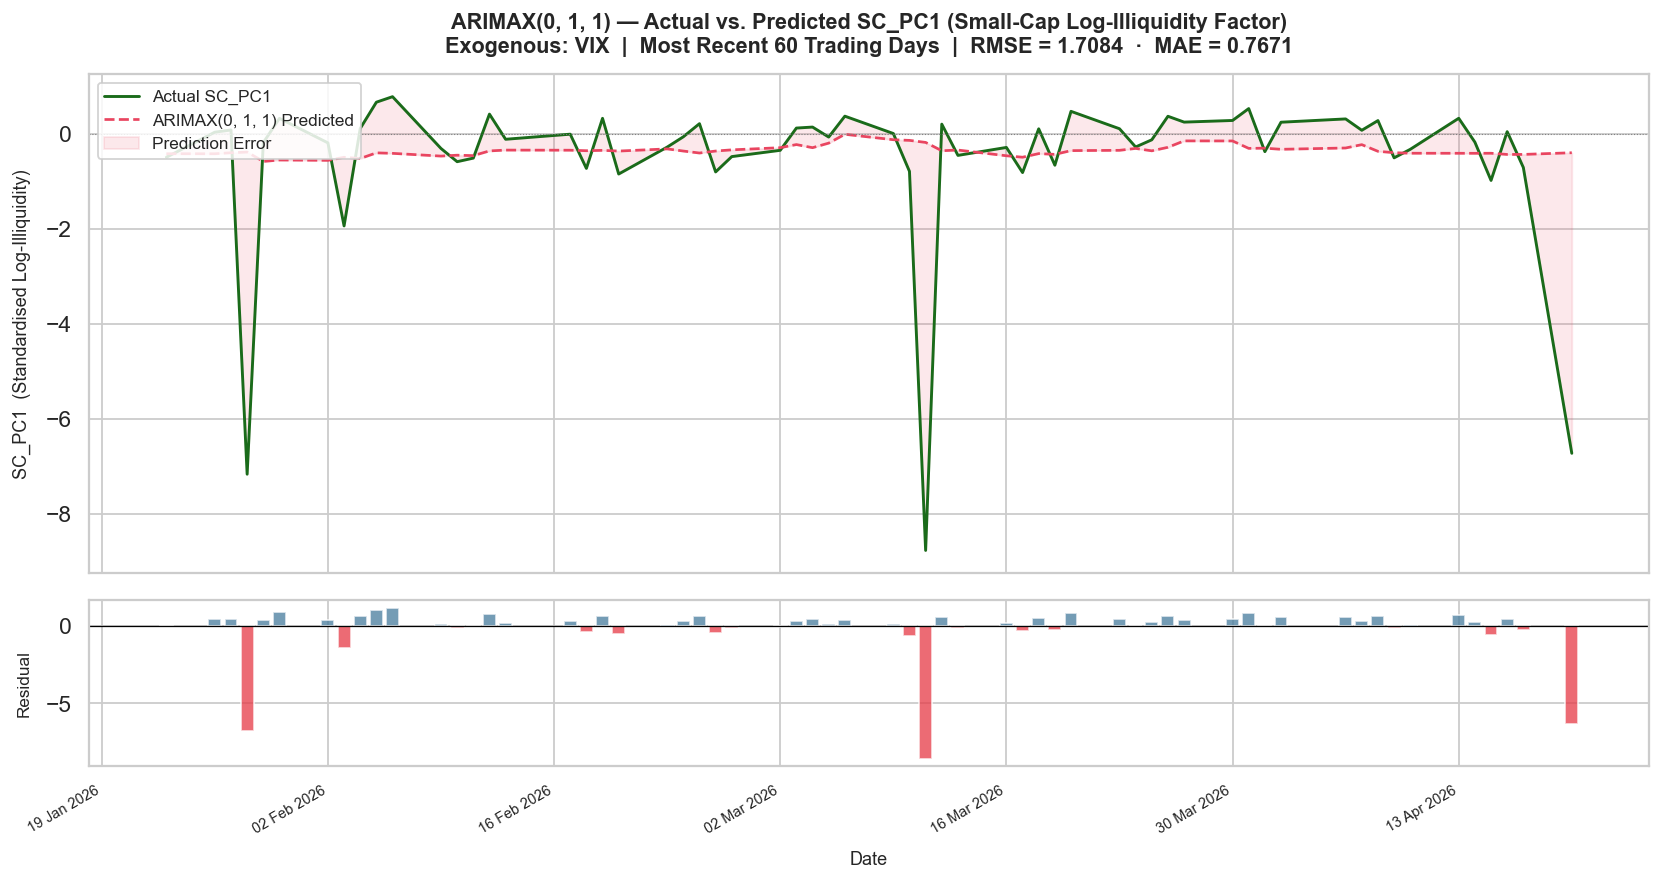

ARIMAX Model Comparison: Mega-Cap vs Small-Cap (last 60 trading days)
                                                     Model   Obs  VIX coef       AIC  RMSE (60d)  MAE (60d)
Mega-Cap (AAPL·MSFT·NVDA·GOOGL·AMZN)       ARIMAX(0, 1, 1)  1253    0.0536 3855.5685      0.7050     0.5501
Small-Cap (MARA·RIOT·SMCI·SOFI·RIVN)       ARIMAX(0, 1, 1)  1112    0.0317 3073.4207      1.7084     0.7671
[Delta Small - Mega]                  Delta (Small - Mega)         -0.0219 -782.1477      1.0034     0.2170

Interpretation:
  Mega-cap RMSE is lower — VIX explains less of small-cap liquidity than expected.


In [21]:
# Step 1: PCA on small-cap log-illiquidity scores
sc_clean    = illiq_scores_sc.dropna()
sc_scaler   = StandardScaler()
sc_X_scaled = sc_scaler.fit_transform(sc_clean)

sc_pca = PCA(n_components=len(SC_TICKERS))
sc_pca.fit(sc_X_scaled)

sc_pc1 = pd.Series(
    sc_pca.transform(sc_X_scaled)[:, 0],
    index=sc_clean.index,
    name="SC_PC1",
)

sc_explained = sc_pca.explained_variance_ratio_
print("Small-Cap PCA Explained Variance")
for i, ev in enumerate(sc_explained, 1):
    print(f"  PC{i}: {ev:.2%}  {'<-- selected' if i == 1 else ''}")
print(f"\n  SC_PC1 captures {sc_explained[0]:.2%} of small-cap variance (vs {explained[0]:.2%} for mega-caps).\n")

# Step 2: ADF stationarity test on SC_PC1
sc_adf_stat, sc_adf_pval, sc_adf_lags, sc_adf_nobs, sc_adf_crit, _ = adfuller(sc_pc1, autolag="AIC")

print("ADF Test on SC_PC1")
print(f"  Test Statistic : {sc_adf_stat:.4f}")
print(f"  p-value        : {sc_adf_pval:.4f}  |  Lags: {sc_adf_lags}")
for level, cv in sc_adf_crit.items():
    print(f"  Critical Value ({level}): {cv:.4f}")
sc_stationary = sc_adf_pval < 0.05
print(f"\n  Result: {'Reject H0 — SC_PC1 is stationary.' if sc_stationary else 'Fail to reject H0 — SC_PC1 is non-stationary.'}\n")

# Step 3: Fit ARIMAX(0,1,1) — same order as mega-cap for a controlled comparison
FIXED_ORDER = (0, 1, 1)

sc_vix_exog = prices["VIX"].reindex(sc_pc1.index).ffill()
sc_ts       = pd.concat([sc_pc1, sc_vix_exog], axis=1, join="inner").dropna()
sc_ts.columns = ["SC_PC1", "VIX"]

sc_endog = sc_ts["SC_PC1"]
sc_exog  = sc_ts[["VIX"]]

print(f"Small-Cap ARIMAX{FIXED_ORDER}")
print(f"  Modelling window: {sc_ts.index[0].date()} to {sc_ts.index[-1].date()}  |  Observations: {len(sc_ts)}\n")

sc_model = ARIMA(sc_endog, exog=sc_exog, order=FIXED_ORDER).fit()

print("ARIMAX Model Results")
print(f"  Model        : ARIMAX{FIXED_ORDER}")
print(f"  Observations : {int(sc_model.nobs)}  |  AIC: {sc_model.aic:.2f}  |  BIC: {sc_model.bic:.2f}")
print(f"  {'Coefficient':<12} {'Value':>10} {'Std Err':>10} {'p-value':>10}")
for name in sc_model.params.index:
    print(f"  {name:<12} {sc_model.params[name]:>10.4f} {sc_model.bse[name]:>10.4f} {sc_model.pvalues[name]:>10.4f}")

# Step 4: In-sample fit — last 60 trading days
LOOKBACK = 60

sc_actual    = sc_endog.iloc[-LOOKBACK:]
sc_predicted = sc_model.fittedvalues.iloc[-LOOKBACK:]
sc_residuals = sc_actual - sc_predicted

sc_rmse = np.sqrt((sc_residuals ** 2).mean())
sc_mae  = sc_residuals.abs().mean()

mega_actual    = endog.iloc[-LOOKBACK:]
mega_predicted = best_model.fittedvalues.iloc[-LOOKBACK:]
mega_residuals = mega_actual - mega_predicted
mega_rmse = np.sqrt((mega_residuals ** 2).mean())
mega_mae  = mega_residuals.abs().mean()

# Plot
fig, (ax_main, ax_resid) = plt.subplots(
    2, 1, figsize=(13, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)

SC_LINE = "#1a6b1a"
SC_PRED = "#e94560"

ax_main.plot(sc_actual.index, sc_actual.values, color=SC_LINE, linewidth=1.6, label="Actual SC_PC1")
ax_main.plot(sc_predicted.index, sc_predicted.values, color=SC_PRED, linewidth=1.5,
             linestyle="--", label=f"ARIMAX{FIXED_ORDER} Predicted")
ax_main.fill_between(sc_actual.index, sc_actual.values, sc_predicted.values,
                     alpha=0.12, color=SC_PRED, label="Prediction Error")
ax_main.axhline(0, color="grey", linewidth=0.6, linestyle=":")
ax_main.set_title(
    f"ARIMAX{FIXED_ORDER} — Actual vs. Predicted SC_PC1 (Small-Cap Log-Illiquidity Factor)\n"
    f"Exogenous: VIX  |  Most Recent {LOOKBACK} Trading Days  |  "
    f"RMSE = {sc_rmse:.4f}  ·  MAE = {sc_mae:.4f}",
    fontsize=12, fontweight="bold", pad=12,
)
ax_main.set_ylabel("SC_PC1  (Standardised Log-Illiquidity)", fontsize=10, labelpad=8)
ax_main.legend(loc="upper left", fontsize=9.5, framealpha=0.85)

ax_resid.bar(sc_residuals.index, sc_residuals.values,
             color=np.where(sc_residuals.values >= 0, "#457b9d", "#e63946"),
             width=0.8, alpha=0.75)
ax_resid.axhline(0, color="black", linewidth=0.7)
ax_resid.set_ylabel("Residual", fontsize=9.5, labelpad=8)
ax_resid.set_xlabel("Date", fontsize=10, labelpad=8)

ax_resid.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
ax_resid.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
plt.setp(ax_resid.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

fig.tight_layout()
plt.show()

# Step 5: Comparison table
comparison = pd.DataFrame(
    {
        "Universe"   : ["Mega-Cap (AAPL·MSFT·NVDA·GOOGL·AMZN)",
                        "Small-Cap (MARA·RIOT·SMCI·SOFI·RIVN)"],
        "Model"      : [f"ARIMAX{best_order}", f"ARIMAX{FIXED_ORDER}"],
        "Obs"        : [len(endog), len(sc_endog)],
        "VIX coef"   : [best_model.params.get("VIX", float("nan")),
                        sc_model.params.get("VIX",  float("nan"))],
        "AIC"        : [best_model.aic, sc_model.aic],
        "RMSE (60d)" : [mega_rmse, sc_rmse],
        "MAE (60d)"  : [mega_mae,  sc_mae],
    }
).set_index("Universe")

improvement = pd.DataFrame(
    {
        "Model"      : ["Delta (Small - Mega)"],
        "Obs"        : [""],
        "VIX coef"   : [comparison["VIX coef"].iloc[1] - comparison["VIX coef"].iloc[0]],
        "AIC"        : [comparison["AIC"].iloc[1]       - comparison["AIC"].iloc[0]],
        "RMSE (60d)" : [sc_rmse  - mega_rmse],
        "MAE (60d)"  : [sc_mae   - mega_mae],
    },
    index=["[Delta Small - Mega]"]
)

full_table = pd.concat([comparison, improvement])

print("ARIMAX Model Comparison: Mega-Cap vs Small-Cap (last 60 trading days)")
print(full_table.to_string(float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else x))

print("\nInterpretation:")
if sc_rmse < mega_rmse:
    pct = (mega_rmse - sc_rmse) / mega_rmse * 100
    print(f"  Small-cap RMSE is {pct:.1f}% lower — VIX explains more of the small-cap liquidity factor.")
else:
    print(f"  Mega-cap RMSE is lower — VIX explains less of small-cap liquidity than expected.")

if comparison["VIX coef"].iloc[1] > comparison["VIX coef"].iloc[0]:
    print(f"  Small-cap VIX coef ({comparison['VIX coef'].iloc[1]:.4f}) > mega-cap ({comparison['VIX coef'].iloc[0]:.4f})")